# Heart Failure Prediction Assignment

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df=pd.read_csv("heart failure.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
df.shape

(299, 13)

In [4]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

## Objective
The goal of this assignment is to analyze the **heart failure clinical records** dataset and build a machine learning model to predict the occurrence of a **death event** in patients with heart failure. You will perform exploratory data analysis (EDA), visualize trends, and apply classification models to predict the target variable.

## Dataset Overview

The dataset consists of 13 variables, each representing clinical features and demographic information of heart failure patients:

1. **age**: Age of the patient (years)
2. **anaemia**: Whether the patient has anaemia (0: no, 1: yes)
3. **creatinine_phosphokinase**: Level of the CPK enzyme in the blood (mcg/L)
4. **diabetes**: Whether the patient has diabetes (0: no, 1: yes)
5. **ejection_fraction**: Percentage of blood leaving the heart with each contraction (%)
6. **high_blood_pressure**: Whether the patient has high blood pressure (0: no, 1: yes)
7. **platelets**: Platelets in the blood (kiloplatelets/mL)
8. **serum_creatinine**: Level of serum creatinine in the blood (mg/dL)
9. **serum_sodium**: Level of serum sodium in the blood (mEq/L)
10. **sex**: Gender of the patient (1: male, 0: female)
11. **smoking**: Whether the patient smokes (0: no, 1: yes)
12. **time**: Follow-up period (days)
13. **DEATH_EVENT**: Whether the patient died during the follow-up period (0: no, 1: yes) [Target Variable]

## Instructions

### 1. Data Exploration (EDA)
- **Task 1**: Load the dataset using pandas and display the first few rows.
- **Task 2**: Check for missing values and clean the data if necessary.
- **Task 3**: Generate summary statistics for the numerical columns.
- **Task 4**: Visualize the distribution of the target variable (`DEATH_EVENT`).
- **Task 5**: Plot histograms or box plots for continuous variables like `age`, `creatinine_phosphokinase`, `ejection_fraction`, `serum_creatinine`, etc.

### 2. Data Visualization
- **Task 6**: Create a correlation matrix heatmap to understand the relationships between the features.
- **Task 7**: Create count plots or bar charts for categorical variables like `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`.
- **Task 8**: Create scatter plots or pair plots for continuous variables like `age` vs `ejection_fraction`, `serum_creatinine`, etc., colored by `DEATH_EVENT`.

### 3. Model Building
- **Task 9**: Split the dataset into features (`X`) and the target variable (`y = DEATH_EVENT`).
- **Task 10**: Perform train-test splitting (70% training, 30% testing) using `train_test_split` from sklearn.
- **Task 11**: Standardize the continuous features using `StandardScaler`.

### 4. Model Training and Evaluation
- **Task 12**: Train a Logistic Regression model and evaluate it using accuracy, precision, recall, and F1-score.
- **Task 13**: Train a K-Nearest Neighbors (KNN) model and evaluate its performance.
- **Task 14**: Train a Decision Tree Classifier and compare its performance with other models.

### 5. Cross Validation
- **Task 15**: Perform K-Fold Cross-Validation (with 5 folds) on the Logistic Regression model to evaluate its performance.
- **Task 16**: Perform Stratified K-Fold Cross-Validation to ensure class balance during cross-validation.

### 6. Model Improvement
- **Task 17**: Use Grid Search or Randomized Search to tune the hyperparameters of the KNN and Decision Tree models.
- **Task 18**: Plot the ROC curves and calculate the AUC for all models to compare their performance visually.

### 7. Conclusion
- **Task 19**: Summarize your findings and explain which model performed best and why. Consider which features were most important for predicting the death event.
- **Task 20**: Suggest potential improvements or next steps for the analysis.

---

## Submission Instructions:
- Submit your notebook file to github with the completed analysis.
- Ensure that the notebook is well-documented with explanations for each step.
- Include visualizations and comments on the results of each model.
- Submit github link only


# 1. Data Exploration (EDA)
Task 1: Load the dataset using pandas and display the first few rows.

In [5]:
import pandas as pd
df=pd.read_csv("heart failure.csv")
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Task 2: Check for missing values and clean the data if necessary.

In [6]:
# Check for missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

# Visualizing missing values using a heatmap (if any)
if missing_values.any():
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Heatmap of Missing Values')
    plt.show()
else:
    print("No missing values detected in the dataset.")



Missing Values:


Series([], dtype: int64)

No missing values detected in the dataset.


Task 3: Generate summary statistics for the numerical columns.

In [7]:
# Display summary statistics
print("\nSummary Statistics:")
display(df.describe())



Summary Statistics:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


Task 4: Visualize the distribution of the target variable (DEATH_EVENT).

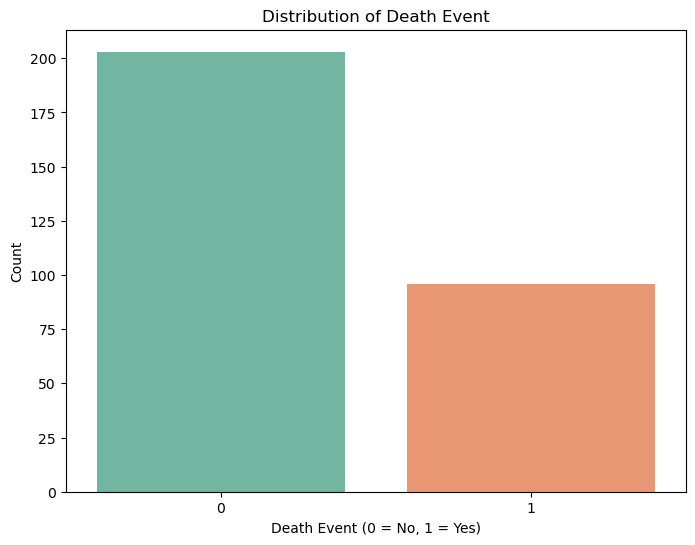

In [8]:
# Visualizing the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='DEATH_EVENT', data=df, palette='Set2')
plt.title('Distribution of Death Event')
plt.xlabel('Death Event (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


Task 5: Plot histograms or box plots for continuous variables like age, creatinine_phosphokinase, ejection_fraction, serum_creatinine, etc.

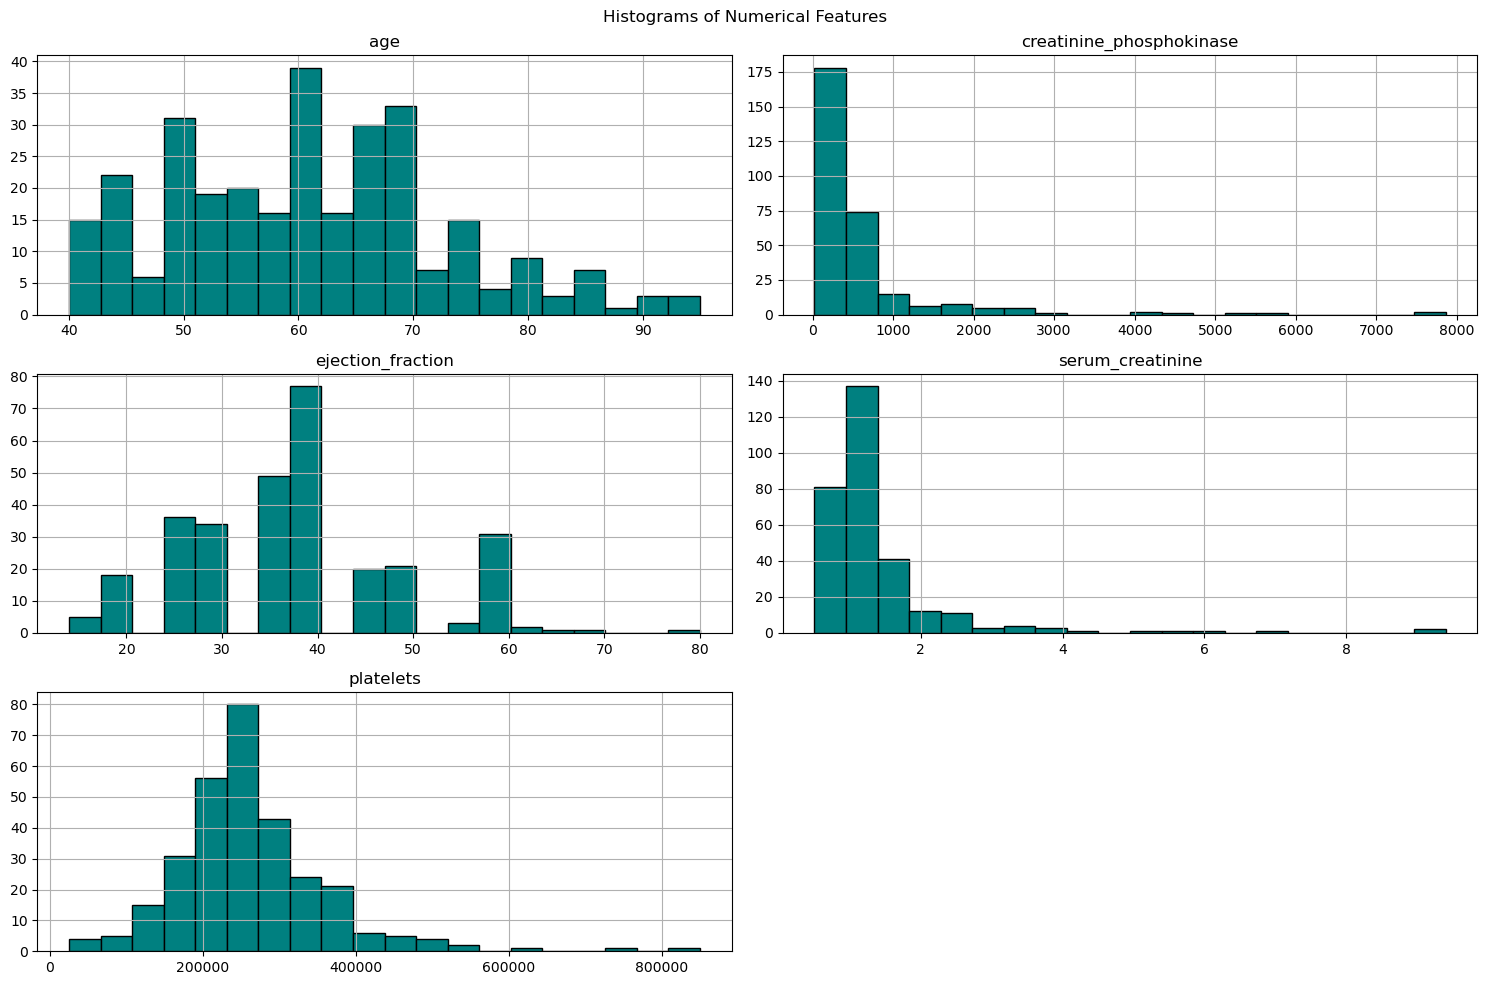

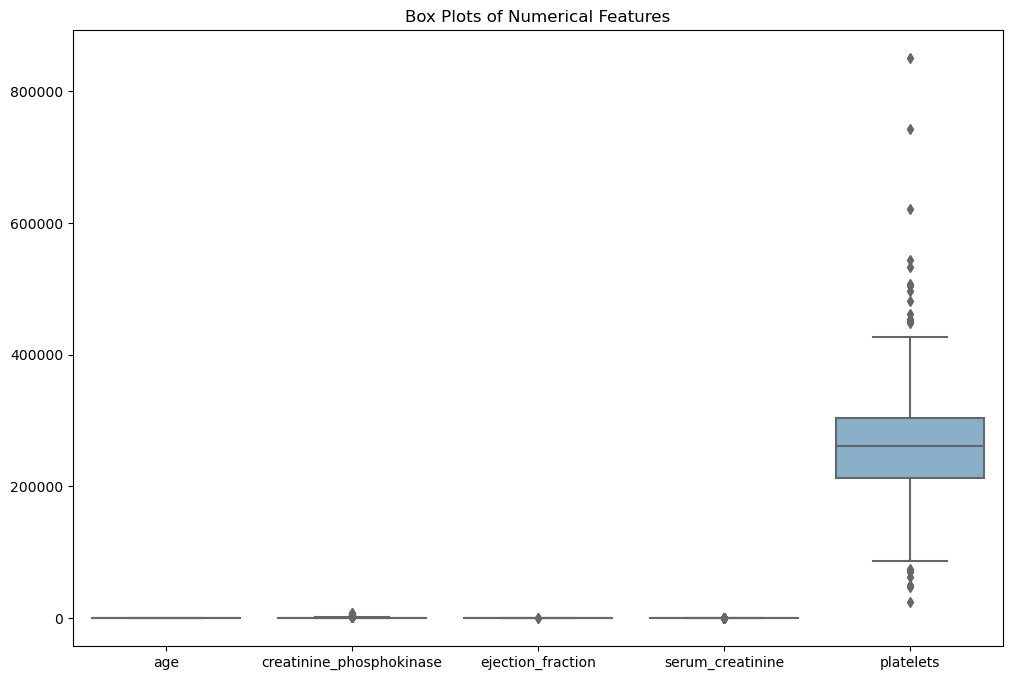

In [9]:
# Plot histograms for continuous variables
numerical_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'serum_creatinine', 'platelets']
df[numerical_features].hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

# Box plots for continuous variables
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numerical_features], palette='Set3')
plt.title('Box Plots of Numerical Features')
plt.show()


# Data Visualization
Task 6: Create a correlation matrix heatmap to understand the relationships between the features.

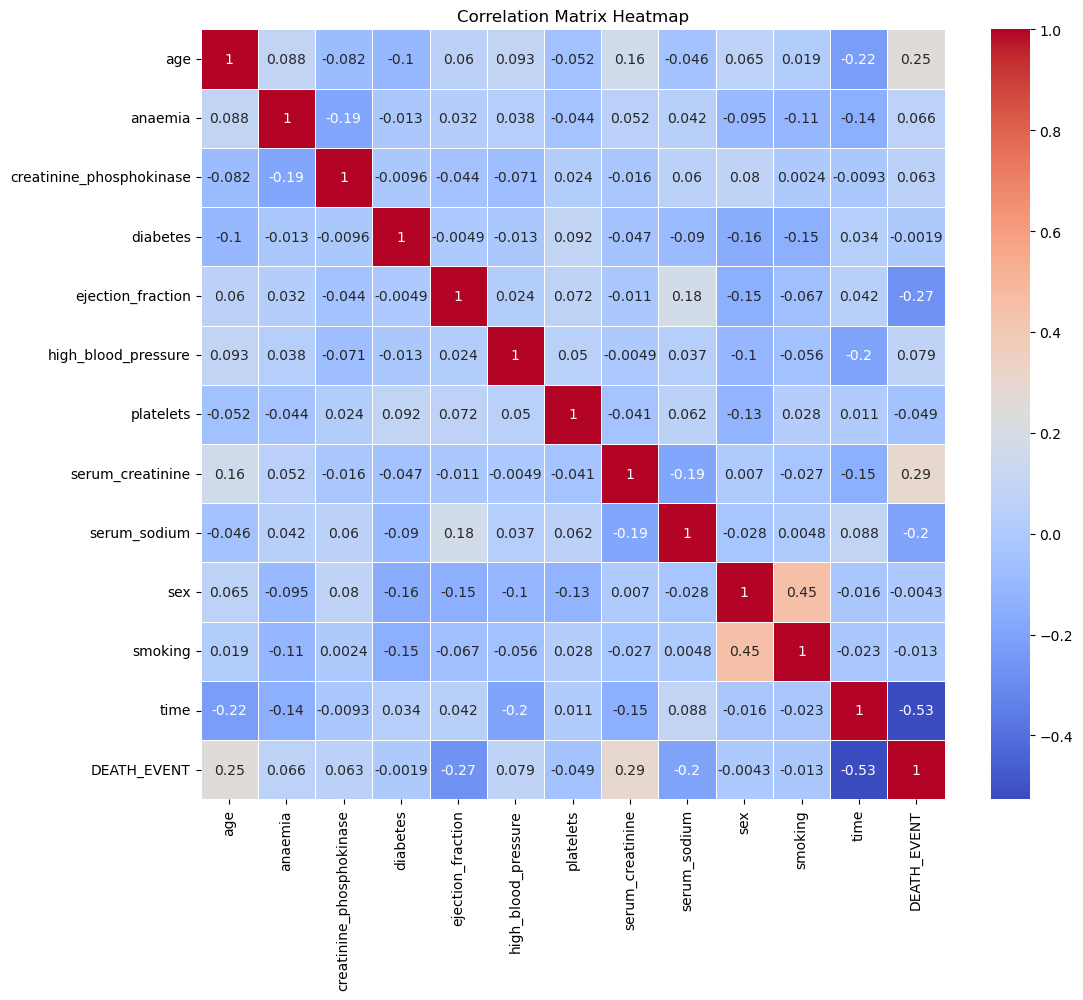

In [10]:
# Correlation matrix heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


Task 7: Create count plots or bar charts for categorical variables like anaemia, diabetes, high_blood_pressure, sex, and smoking.

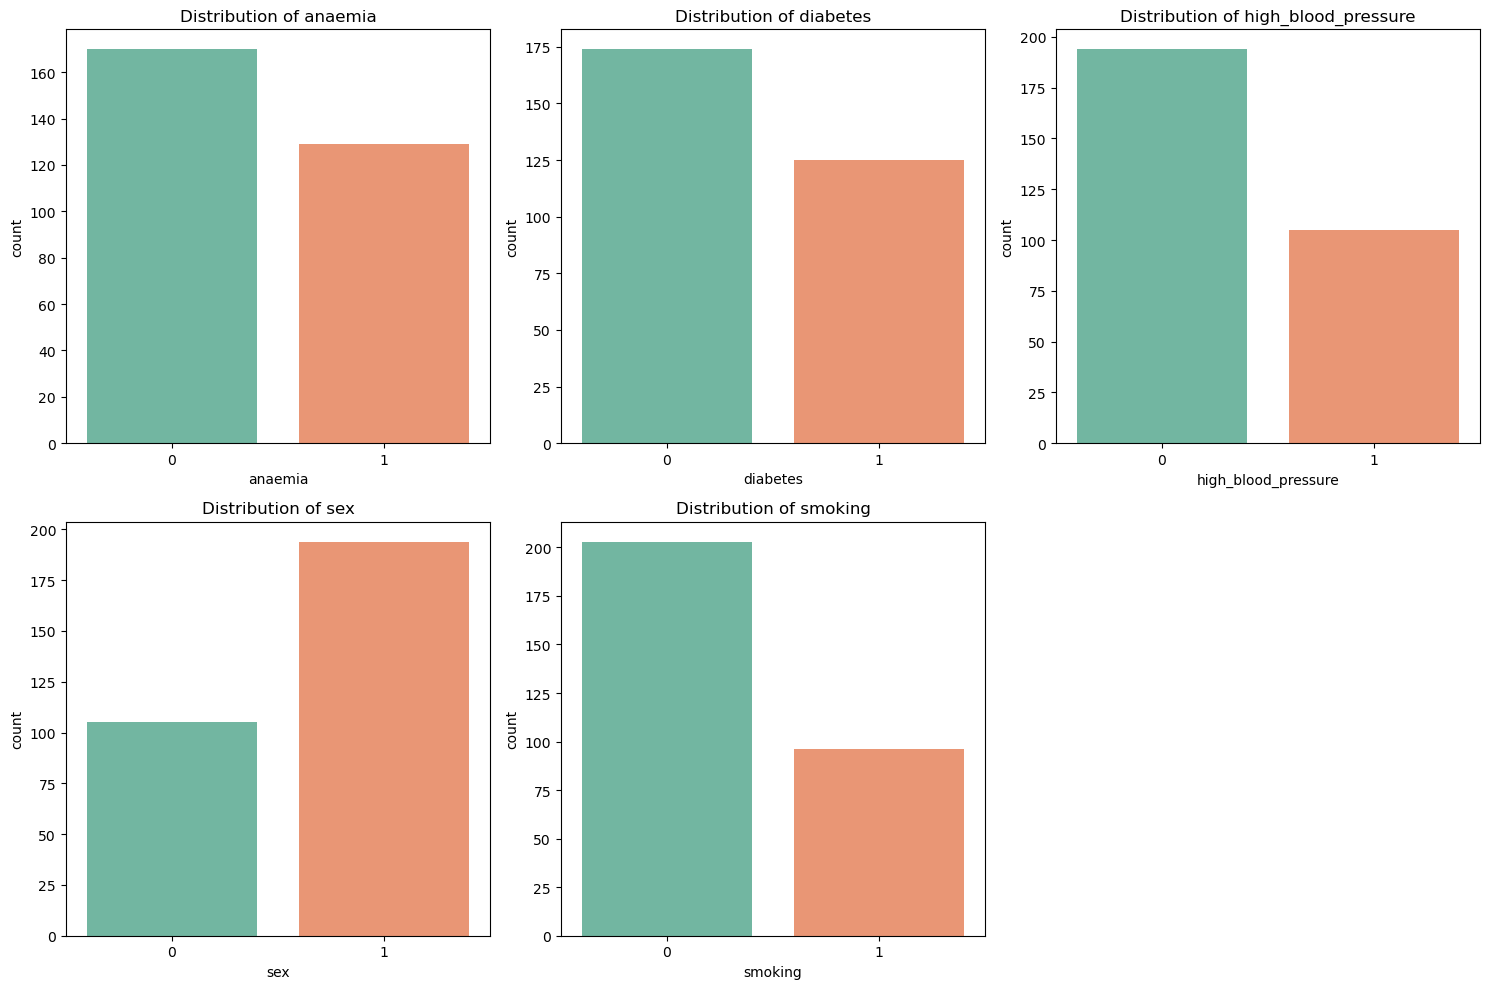

In [11]:
# Count plots for categorical variables
categorical_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
plt.figure(figsize=(15, 10))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=feature, data=df, palette='Set2')
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()


Task 8: Create scatter plots or pair plots for continuous variables like age vs ejection_fraction, serum_creatinine, etc., colored by DEATH_EVENT.

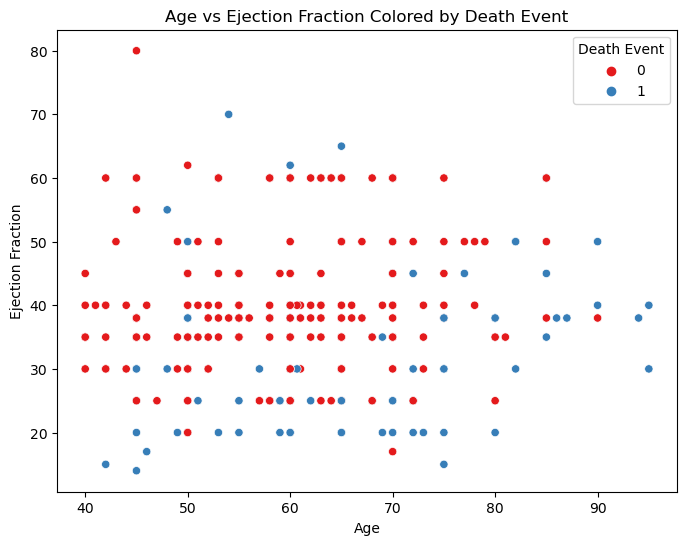

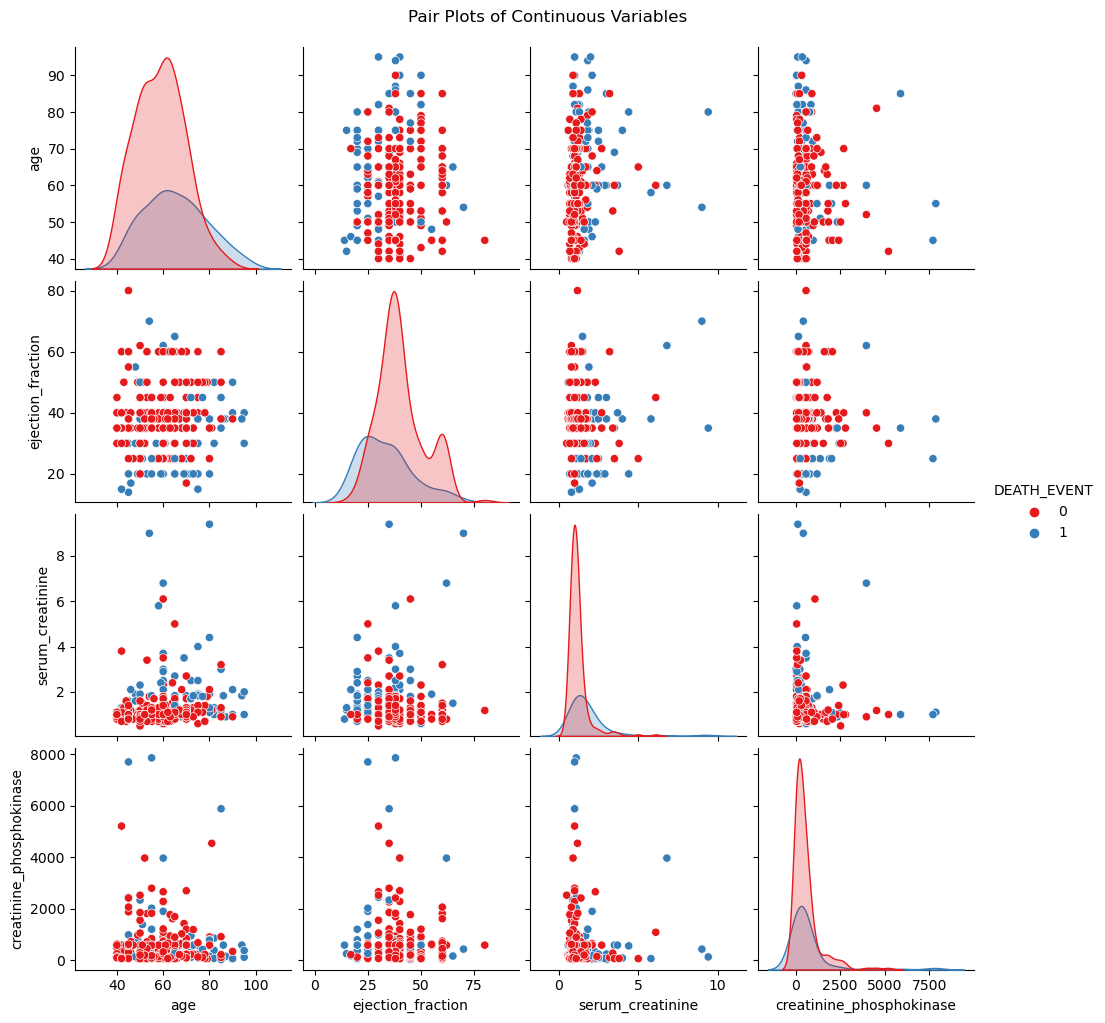

In [12]:
# Scatter plot for age vs ejection_fraction colored by DEATH_EVENT
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='ejection_fraction', hue='DEATH_EVENT', data=df, palette='Set1')
plt.title('Age vs Ejection Fraction Colored by Death Event')
plt.xlabel('Age')
plt.ylabel('Ejection Fraction')
plt.legend(title='Death Event', loc='upper right')
plt.show()

# Pair plots for continuous variables colored by DEATH_EVENT
sns.pairplot(df, vars=['age', 'ejection_fraction', 'serum_creatinine', 'creatinine_phosphokinase'], hue='DEATH_EVENT', palette='Set1')
plt.suptitle('Pair Plots of Continuous Variables', y=1.02)
plt.show()


Model Building
Task 9: Split the dataset into features (X) and the target variable (y = DEATH_EVENT).

In [13]:
# Splitting dataset into features and target variable
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']


Task 10: Perform train-test splitting (70% training, 30% testing) using train_test_split from sklearn.

In [14]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


Task 11: Standardize the continuous features using StandardScaler.

In [15]:
from sklearn.preprocessing import StandardScaler

# Standardizing the continuous features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Model Training and Evaluation
Task 12: Train a Logistic Regression model and evaluate it using accuracy, precision, recall, and F1-score.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Training Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model Evaluation:")
print(classification_report(y_test, y_pred_log_reg))


Logistic Regression Model Evaluation:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        61
           1       0.79      0.66      0.72        29

    accuracy                           0.83        90
   macro avg       0.82      0.79      0.80        90
weighted avg       0.83      0.83      0.83        90



Task 13: Train a K-Nearest Neighbors (KNN) model and evaluate its performance.

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Training KNN model
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)

# Evaluation
print("KNN Model Evaluation:")
print(classification_report(y_test, y_pred_knn))


KNN Model Evaluation:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80        61
           1       0.57      0.28      0.37        29

    accuracy                           0.70        90
   macro avg       0.65      0.59      0.59        90
weighted avg       0.67      0.70      0.66        90



Task 14: Train a Decision Tree Classifier and compare its performance with other models.

In [18]:
from sklearn.tree import DecisionTreeClassifier

# Training Decision Tree Classifier
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt_classifier.predict(X_test_scaled)

# Evaluation
print("Decision Tree Classifier Evaluation:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Classifier Evaluation:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        61
           1       0.73      0.66      0.69        29

    accuracy                           0.81        90
   macro avg       0.79      0.77      0.78        90
weighted avg       0.81      0.81      0.81        90



# Cross Validation
Task 15: Perform K-Fold Cross-Validation (with 5 folds) on the Logistic Regression model to evaluate its performance.

In [19]:
from sklearn.model_selection import cross_val_score

# K-Fold Cross-Validation
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Logistic Regression CV Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Logistic Regression CV Accuracy Scores: [0.80952381 0.71428571 0.83333333 0.85714286 0.85365854]
Mean CV Accuracy: 0.813588850174216


Task 16: Perform Stratified K-Fold Cross-Validation to ensure class balance during cross-validation.

In [20]:
from sklearn.model_selection import StratifiedKFold

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5)
stratified_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=skf, scoring='accuracy')
print("Stratified K-Fold CV Accuracy Scores:", stratified_cv_scores)
print("Mean Stratified CV Accuracy:", stratified_cv_scores.mean())


Stratified K-Fold CV Accuracy Scores: [0.80952381 0.71428571 0.83333333 0.85714286 0.85365854]
Mean Stratified CV Accuracy: 0.813588850174216


# Model Improvement
Task 17: Use Grid Search or Randomized Search to tune the hyperparameters of the KNN and Decision Tree models.

In [21]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for KNN
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train_scaled, y_train)

print("Best KNN Parameters:", grid_knn.best_params_)


Best KNN Parameters: {'n_neighbors': 11}


Task 18: Plot the ROC curves and calculate the AUC for all models to compare their performance visually.

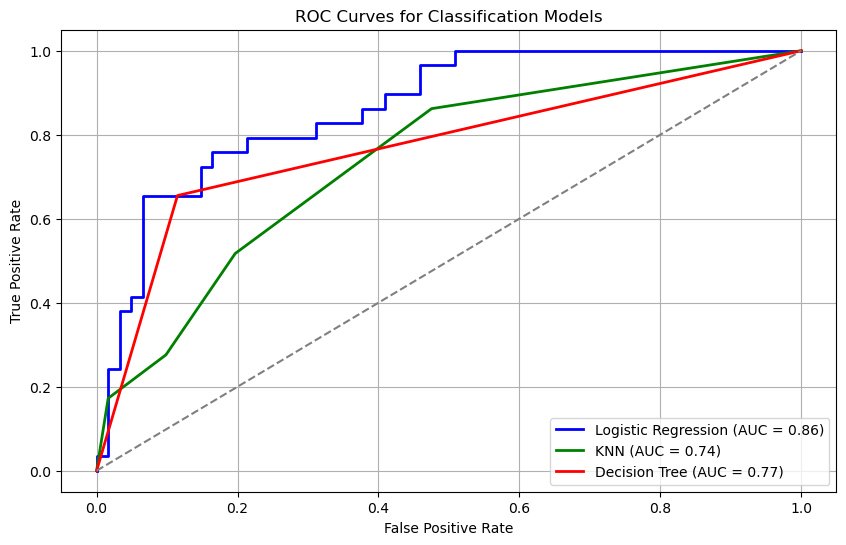

In [23]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve for Logistic Regression
y_pred_proba_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

# Calculate ROC curve for KNN
y_pred_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Calculate ROC curve for Decision Tree
y_pred_proba_dt = dt_classifier.predict_proba(X_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plotting the ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_log_reg, tpr_log_reg, color='blue', lw=2, label='Logistic Regression (AUC = {:.2f})'.format(roc_auc_log_reg))
plt.plot(fpr_knn, tpr_knn, color='green', lw=2, label='KNN (AUC = {:.2f})'.format(roc_auc_knn))
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, label='Decision Tree (AUC = {:.2f})'.format(roc_auc_dt))

# Plot diagonal line for random guessing
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')

# Labels and title
plt.title('ROC Curves for Classification Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()
